# Step 1

In [38]:
!pip install ucimlrepo


In [39]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:
forest_fires = fetch_ucirepo(id=162)

X = forest_fires.data.features
y = forest_fires.data.targets

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0



Target:


,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


# Step 2- EDA 

In [41]:
print(X.info())


<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None


In [42]:
print(X.describe(include="all"))


                 X           Y month  day        FFMC         DMC          DC  \
count   517.000000  517.000000   517  517  517.000000  517.000000  517.000000   
unique         NaN         NaN    12    7         NaN         NaN         NaN   
top            NaN         NaN   aug  sun         NaN         NaN         NaN   
freq           NaN         NaN   184   95         NaN         NaN         NaN   
mean      4.669246    4.299807   NaN  NaN   90.644681  110.872340  547.940039   
std       2.313778    1.229900   NaN  NaN    5.520111   64.046482  248.066192   
min       1.000000    2.000000   NaN  NaN   18.700000    1.100000    7.900000   
25%       3.000000    4.000000   NaN  NaN   90.200000   68.600000  437.700000   
50%       4.000000    4.000000   NaN  NaN   91.600000  108.300000  664.200000   
75%       7.000000    5.000000   NaN  NaN   92.900000  142.400000  713.900000   
max       9.000000    9.000000   NaN  NaN   96.200000  291.300000  860.600000   

               ISI        t

In [43]:

print("\nTarget information:")
print(y.info())



Target information:
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB
None


In [44]:
print(y.describe())

              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000


In [45]:
df = pd.concat([X, y], axis=1)

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [46]:
print("Dataset shape:", df.shape)

Dataset shape: (517, 13)


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


In [48]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [49]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [50]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4


In [51]:
df.drop_duplicates(inplace=True)

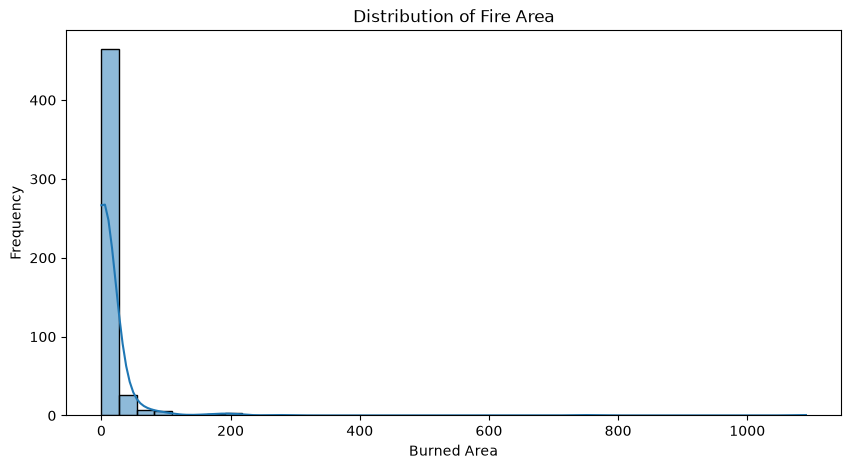

In [52]:
# Check the distribution of the target variable 'area', representing the burned area of the forest fire.
plt.figure(figsize=(10, 5))

sns.histplot(df["area"], bins=40, kde=True)

plt.title("Distribution of Fire Area")
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.show()

- The target is strongly right-skewed, with many fires having relatively small burned areas and a smaller number of very large fires

In [53]:
# Apply log transformation to the "area" column to reduce skewness and improve model performance 
df["log_area"] = np.log1p(df["area"])
df[["area", "log_area"]].describe()

,area,log_area
count,513.000000,513.000000
mean,12.891598,1.113081
std,63.892586,1.397685
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.540000,0.431782
75%,6.570000,2.024193
max,1090.840000,6.995620


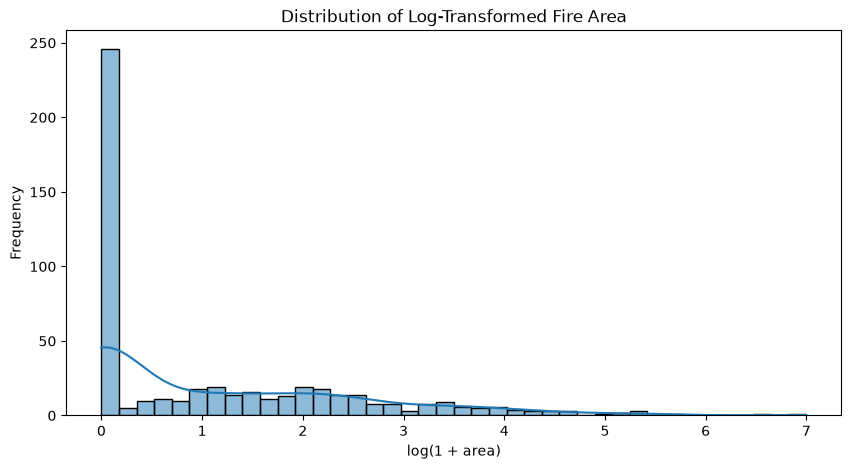

In [55]:
# histplot of the log-transormed "area"
plt.figure(figsize=(10, 5))

sns.histplot(df["log_area"], bins=40, kde=True)

plt.title("Distribution of Log-Transformed Fire Area")
plt.xlabel("log(1 + area)")
plt.ylabel("Frequency")
plt.show()

#### Target distribution

- The original fire-area variable is strongly right-skewed, indicating that most observations correspond to relatively small fires while a small number of observations represent larger fires.

- A log transformation reduces the influence of extreme observations and produces a more balanced target distribution. Hence, the transformed target will be used for regression analysis.

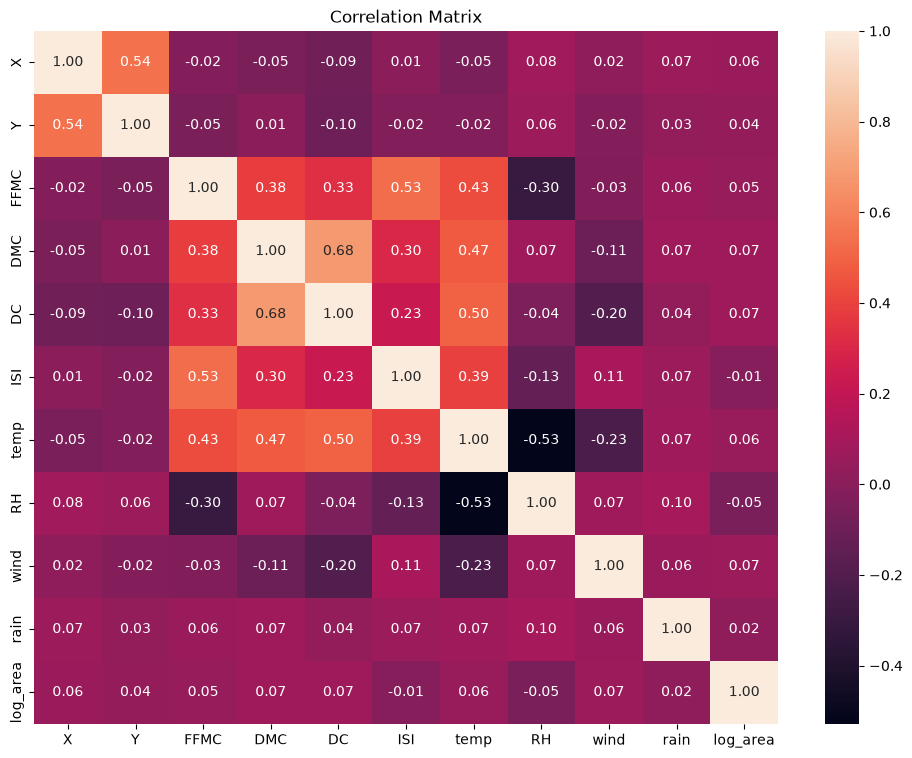

In [59]:
# Correlation Analysis of numerical Features
numerical_features = [
    "X", "Y", "FFMC", "DMC", "DC", "ISI",
    "temp", "RH", "wind", "rain"
]

plt.figure(figsize=(12, 9))

correlation_matrix = df[numerical_features + ["log_area"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Findings

The correlation matrix was used to identify linear relationships between the environmental variables and fire size.

The results show that there were no environmental variables that have meaningful linear relationship with `log_area`. The strongest absolute correlations were negligible: DMC and DC (both at +0.07), followed by RH at -0.05. Suggesting that fire size is not driven by simple linear trends.

Since correlation does not establish causation, these relationships will be evaluated further through modelling to capture potential threshold effects and interactions between variables.

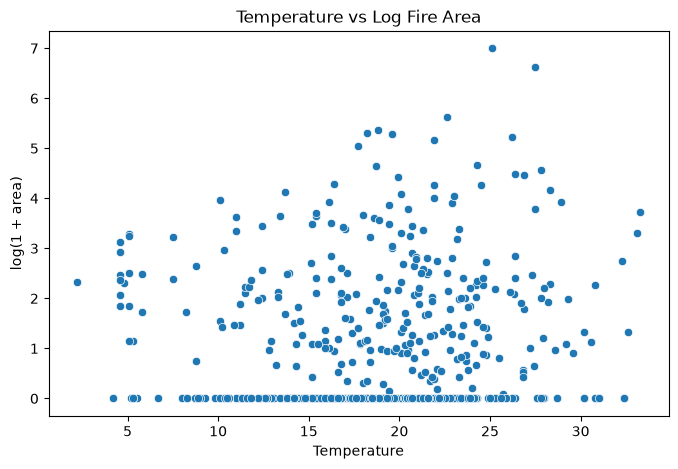

In [61]:
# Temperature vs Log Fire Area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="log_area"
)

plt.title("Temperature vs Log Fire Area")
plt.xlabel("Temperature")
plt.ylabel("log(1 + area)")
plt.show()

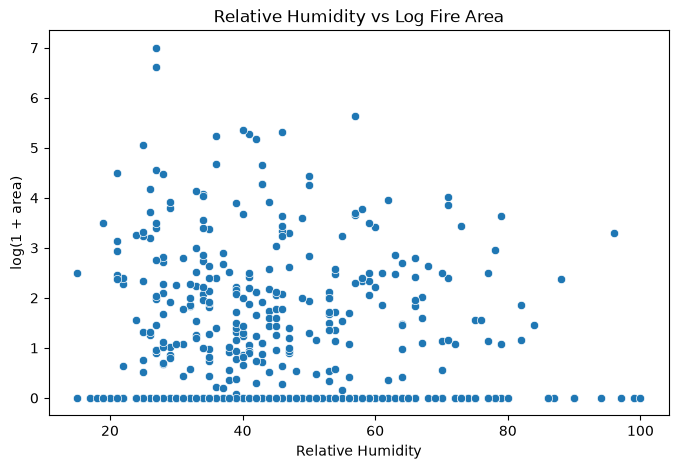

In [62]:
# Fire size vs humidity
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="RH",
    y="log_area"
)

plt.title("Relative Humidity vs Log Fire Area")
plt.xlabel("Relative Humidity")
plt.ylabel("log(1 + area)")
plt.show()

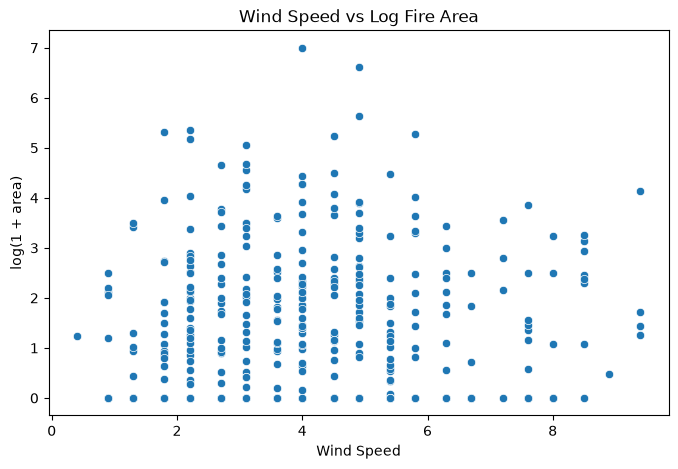

In [64]:
# Wind speed vs Log Fire Area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="wind",
    y="log_area"
)

plt.title("Wind Speed vs Log Fire Area")
plt.xlabel("Wind Speed")
plt.ylabel("log(1 + area)")
plt.show()

# Step 3- Fit Regression Models